
# EDA_FINAL_TESIS_MOLINO_1D_15MIN

## Análisis Exploratorio de Datos y Diagnóstico Estadístico

**Predicción de la Potencia Consumida por un Molino de Bolas en la Industria Minera mediante Modelos de Series Temporales**

Este notebook fue creado como complemento de la tesis. No modifica los notebooks finales de ARIMAX, XGBoost ni TFT.

Objetivos:

- Auditar el dataset original de 5 segundos.
- Reproducir exactamente la agregación temporal utilizada por los modelos.
- Trabajar con el dataset final de 15 segundos.
- Generar boxplots y análisis estadísticos.
- Realizar ACF/PACF únicamente sobre el conjunto de entrenamiento para evitar fuga de información.
- Documentar la división temporal utilizada en la investigación.

Flujo:

444580 registros (5 segundos)
→ agrupación de 3 mediciones reales
→ 148193 observaciones (15 segundos)
→ Train / Validation / Test
→ Análisis exploratorio


In [1]:

# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12,5)


In [2]:

# Carga del archivo original

df_raw = pd.read_csv("1D_POT_2.csv")

print("Registros originales:", len(df_raw))

df_raw.head()


Registros originales: 444580


,FECHA,F80,T,AA,AD,POT
0,1/8/2026 14:45:00,5937.720703,259.197083,2182.698730,5989.462402,2.364831
1,1/8/2026 14:45:05,5937.020020,259.124054,2182.784912,5980.457031,2.364779
2,1/8/2026 14:45:10,5936.318848,259.050995,2182.871338,5903.375977,2.364728
3,1/8/2026 14:45:15,5935.617676,258.977966,2182.957520,5898.351074,2.364676
4,1/8/2026 14:45:20,5934.916504,258.904907,2183.043701,5907.456543,2.364624


In [3]:

# Auditoría inicial

df_raw['FECHA'] = pd.to_datetime(
    df_raw['FECHA'],
    dayfirst=True
)

df_raw = df_raw.sort_values('FECHA').reset_index(drop=True)

print("Fecha inicial:", df_raw.FECHA.min())
print("Fecha final:", df_raw.FECHA.max())

print("\nValores faltantes:")
display(df_raw.isna().sum())

print("\nDuplicados:")
print(df_raw.duplicated().sum())

print("\nIntervalos temporales:")
display(df_raw.FECHA.diff().dt.total_seconds().value_counts().head())


Fecha inicial: 2026-08-01 14:45:00
Fecha final: 2026-08-27 08:13:15

Valores faltantes:


FECHA    0
F80      0
T        0
AA       0
AD       0
POT      0
dtype: int64


Duplicados:
0

Intervalos temporales:


5.0    444579
Name: FECHA, dtype: int64


# Agregación temporal a 15 segundos

Se mantiene el criterio utilizado en la tesis:

- Datos originales: mediciones cada 5 segundos.
- Cada observación del modelo corresponde al promedio de tres mediciones reales.
- No se imputan valores de POT.
- Solo se conservan intervalos completos.


In [4]:

# Creación de intervalos de 15 segundos

df_raw['grupo_15s'] = (
    df_raw['FECHA'].astype('int64') // 10**9
) // 15


conteo = df_raw.groupby('grupo_15s').size()

grupos_validos = conteo[conteo == 3].index


df_15s = (
    df_raw[df_raw['grupo_15s'].isin(grupos_validos)]
    .groupby('grupo_15s')
    .agg({
        'FECHA':'first',
        'F80':'mean',
        'T':'mean',
        'AA':'mean',
        'AD':'mean',
        'POT':'mean'
    })
    .reset_index(drop=True)
)


print("Dataset final:")
print(df_15s.shape)

df_15s.head()


Dataset final:
(148193, 6)


,FECHA,F80,T,AA,AD,POT
0,2026-08-01 14:45:00,5937.019857,259.124044,2182.784993,5957.765137,2.364779
1,2026-08-01 14:45:15,5934.916504,258.904917,2183.043701,5907.456706,2.364624
2,2026-08-01 14:45:30,5932.813314,258.674642,2183.302490,5908.003907,2.364469
3,2026-08-01 14:45:45,5930.709961,258.435557,2183.561279,5896.214355,2.364313
4,2026-08-01 14:46:00,5928.606608,258.196462,2183.819987,5907.605794,2.364158


In [5]:

# Verificación dataset final

print("Observaciones esperadas aproximadas: 148193")
print("Observaciones obtenidas:", len(df_15s))

print("\nFrecuencia temporal:")
display(df_15s.FECHA.diff().dt.total_seconds().value_counts().head())


Observaciones esperadas aproximadas: 148193
Observaciones obtenidas: 148193

Frecuencia temporal:


15.0    148192
Name: FECHA, dtype: int64

In [6]:

# Estadísticos descriptivos

variables = ['F80','T','AA','AD','POT']

estadisticos = df_15s[variables].describe().T

estadisticos


,count,mean,std,min,25%,50%,75%,max
F80,148193.0,6818.918611,879.575286,0.000001,6467.866699,6744.149414,7074.865397,10382.029300
T,148193.0,272.198056,19.628678,0.205997,262.462240,276.272634,284.683818,312.996562
AA,148193.0,2297.235466,355.688533,749.931763,2031.419759,2310.317058,2529.819173,3314.998779
AD,148193.0,5048.966270,635.486513,3330.113525,4569.186361,4960.185221,5598.220866,6744.123047
POT,148193.0,2.312818,0.030194,2.229676,2.288452,2.307360,2.336659,2.443293



# Boxplots del dataset final

Estas figuras corresponden al conjunto después de la agregación temporal a 15 segundos.


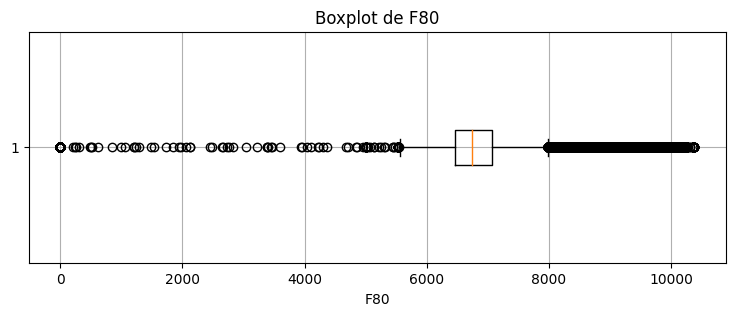

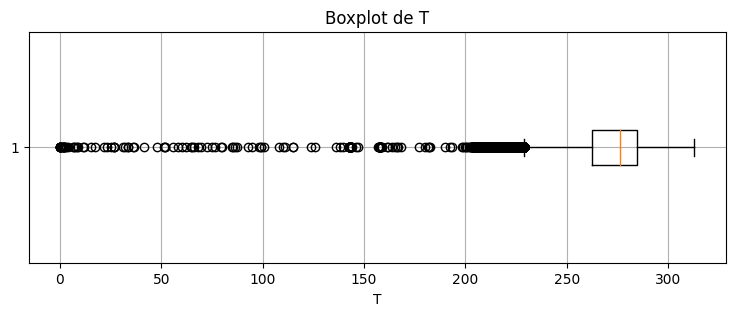

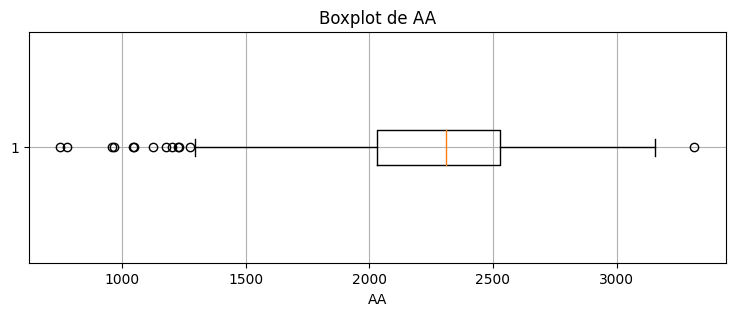

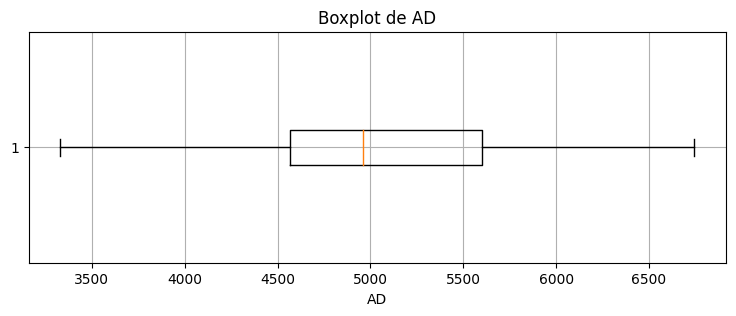

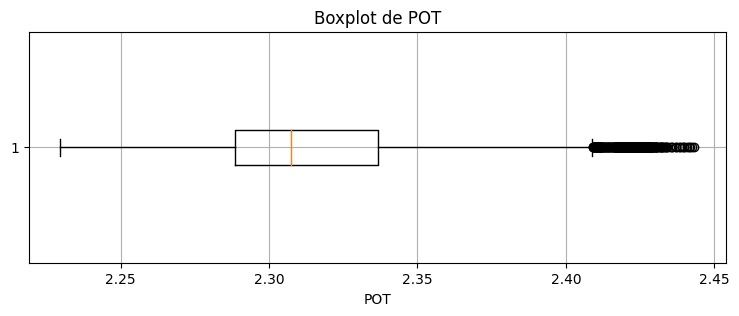

In [7]:

for variable in variables:

    plt.figure(figsize=(9,3))

    plt.boxplot(
        df_15s[variable].dropna(),
        vert=False
    )

    plt.title(f"Boxplot de {variable}")
    plt.xlabel(variable)
    plt.grid(True)

    plt.show()


,F80,T,AA,AD,POT
F80,1.000000,-0.349501,-0.095853,-0.011939,-0.149862
T,-0.349501,1.000000,0.117018,0.102732,0.109135
AA,-0.095853,0.117018,1.000000,-0.230304,0.121796
AD,-0.011939,0.102732,-0.230304,1.000000,0.260913
POT,-0.149862,0.109135,0.121796,0.260913,1.000000


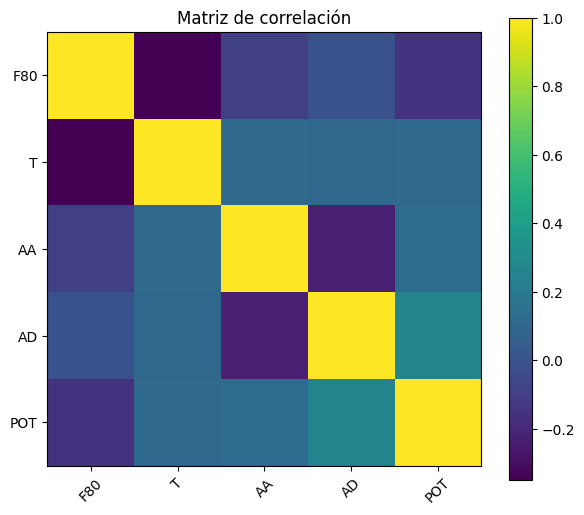

In [8]:

# Matriz de correlación

corr = df_15s[variables].corr()

display(corr)

plt.figure(figsize=(7,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(variables)),
    variables,
    rotation=45
)

plt.yticks(
    range(len(variables)),
    variables
)

plt.title("Matriz de correlación")

plt.show()



# División temporal utilizada en la tesis

La división se realiza después de la agregación temporal:

- Entrenamiento: 113633 observaciones.
- Validación: 17280 observaciones.
- Prueba: 17280 observaciones.

No existe mezcla aleatoria entre periodos.


In [9]:

TRAIN_SIZE = 113633
VAL_SIZE = 17280
TEST_SIZE = 17280


train = df_15s.iloc[:TRAIN_SIZE].copy()

val = df_15s.iloc[
    TRAIN_SIZE:
    TRAIN_SIZE + VAL_SIZE
].copy()

test = df_15s.iloc[
    TRAIN_SIZE + VAL_SIZE:
    TRAIN_SIZE + VAL_SIZE + TEST_SIZE
].copy()


print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)


print("\nFechas")

print(
    "Train:",
    train.FECHA.min(),
    "-",
    train.FECHA.max()
)

print(
    "Validation:",
    val.FECHA.min(),
    "-",
    val.FECHA.max()
)

print(
    "Test:",
    test.FECHA.min(),
    "-",
    test.FECHA.max()
)


Train: (113633, 6)
Validation: (17280, 6)
Test: (17280, 6)

Fechas
Train: 2026-08-01 14:45:00 - 2026-08-21 08:13:00
Validation: 2026-08-21 08:13:15 - 2026-08-24 08:13:00
Test: 2026-08-24 08:13:15 - 2026-08-27 08:13:00



# Diagnóstico ACF/PACF

Importante:

El análisis de autocorrelación se realiza únicamente sobre TRAIN.

Esto evita utilizar información futura proveniente de validación o prueba.


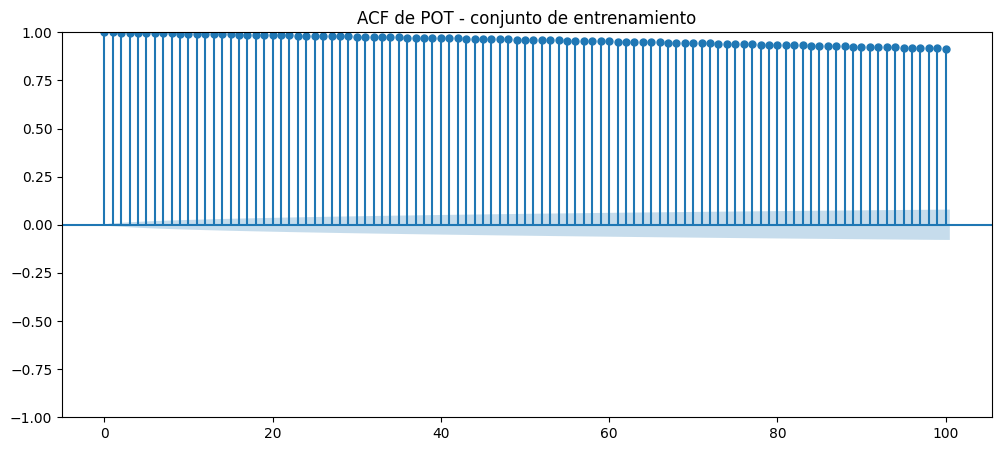

In [10]:

# ACF de POT en entrenamiento

plot_acf(
    train['POT'],
    lags=100
)

plt.title(
    "ACF de POT - conjunto de entrenamiento"
)

plt.show()


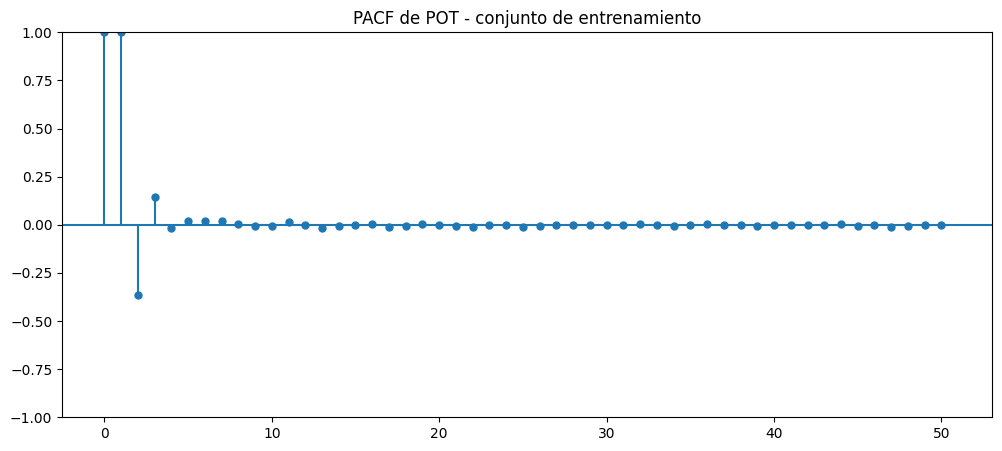

In [11]:

# PACF de POT en entrenamiento

plot_pacf(
    train['POT'],
    lags=50,
    method='ywm'
)

plt.title(
    "PACF de POT - conjunto de entrenamiento"
)

plt.show()



# Parámetros de modelamiento documentados

Los siguientes elementos provienen de la configuración de los notebooks de modelamiento:

- Frecuencia del modelo: 15 segundos.
- Contexto temporal: derivado de INPUT_CHUNK_LENGTH.
- Horizonte futuro: derivado de OUTPUT_CHUNK_LENGTH.
- Evaluación: rolling origin mediante ROLLING_STRIDE.
- Benchmark: persistencia del último valor observado.

Este notebook no ejecuta modelos; únicamente documenta la preparación y análisis del conjunto de datos.



# Conclusiones del EDA

Completar después de la ejecución:

1. Calidad del dataset.
2. Evidencia de continuidad temporal.
3. Distribución de variables operacionales.
4. Presencia de autocorrelación temporal en POT.
5. Justificación del uso de modelos de series temporales.
